# Utilização do algoritmo ODIN para análise de desvio semântico em imagens de satélite.

## Experimento
Utilizando os dados do EuroSAT da biblioteca torchvision, fazer o fine-tuning da rede MobileNetV2, pré-treinada com pesos da ImageNet, em 7 das 10 classes e analisar o desempenho do algoritmo ODIN para detecção de desvio semântico nas 3 classes reestantes.

## Metodologia
No primeiro momento é feito o fine-tuning congelando toda a rede e treinando apenas a camada fully-connected com 7 saídas. Com a rede treinada sobre a tarefa é então realizada uma busca dentre os melhores parâmetros para o algoritmo ODIN que detecta melhor os dados que estão fora da distribuição.

Em seguida o fine-tuning é feito descongelando a última camada convolucional da rede e o mesmo procedimento de seleção de parâmetros para o ODIN é realizado.

# Bibliotecas e módulos utilizados

In [1]:
import torch
import torchvision
from torchvision.datasets import EuroSAT
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import random_split, Subset, DataLoader
from torchvision.models import mobilenet_v2
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Setup para reproducibilidade

In [2]:
def seed_everything(seed: int):
    import random, os
    import numpy as np
    import torch

    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed = 42
seed_everything(seed)

# Dataset


In [3]:
# Normalização das imagens
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [4]:
dataset = EuroSAT(root='./data', download=True, transform=transform)

dataset.classes

100%|██████████| 94.3M/94.3M [00:00<00:00, 110MB/s]


['AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River',
 'SeaLake']

## Divisão entre treino validação e teste

In [5]:
# Classes fora da distribuição
ood_classes = [9, 8, 7]

for item in ood_classes:
  print(dataset.classes[item])

num_classes = len(dataset.classes) - len(ood_classes)

SeaLake
River
Residential


In [6]:
id_indices = [i for i, x in enumerate(dataset.imgs) if x[1] not in ood_classes]
ood_indices = [i for i, x in enumerate(dataset.imgs) if x[1] in ood_classes]

In [7]:
id_dataset = Subset(dataset, id_indices)
ood_dataset = Subset(dataset, ood_indices)

In [8]:
ds_size = len(id_dataset)
train_size = int(0.8 * ds_size)
dev_size = int(0.1 * ds_size)
test_size = ds_size - (train_size + dev_size)

print(f"{ds_size=}, {train_size=}, {dev_size=}, {test_size=}")

ds_size=18500, train_size=14800, dev_size=1850, test_size=1850


In [9]:
generator = torch.Generator().manual_seed(seed)
trainset, devset, testset = random_split(
    id_dataset, [train_size, dev_size, test_size], generator=generator
)

In [10]:
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
devloader = DataLoader(devset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=True)

# Modelo utilizado

In [16]:
model = mobilenet_v2(torchvision.models.MobileNet_V2_Weights)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 68.1MB/s]


In [17]:
# Freeze model layers
for param in model.parameters():
  param.requires_grad = False

In [18]:
in_features = model.classifier[1].in_features

model.classifier = torch.nn.Sequential(
    torch.nn.Linear(in_features, num_classes)
)

model.classifier

Sequential(
  (0): Linear(in_features=1280, out_features=7, bias=True)
)

# Train and validation loop

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [12]:
def train(model, trainloader, optmizer, criterion, device):
  model.train()
  total_loss, correct, total = 0.0, 0.0, 0.0

  for xb, yb in trainloader:
    xb, yb = xb.to(device), yb.to(device)

    optmizer.zero_grad()
    y_hat = model(xb)
    loss = criterion(y_hat, yb)
    loss.backward()
    optmizer.step()

    total_loss += loss.item() * xb.size(0)
    pred = y_hat.argmax(dim=1)
    correct += (pred == yb).sum().item()
    total += yb.size(0)

  return total_loss / total, correct / total

In [13]:
def validate(model, devloader, criterion, device):
  model.eval()

  total_loss, correct, total = 0.0, 0.0, 0.0

  with torch.no_grad():
    for xb, yb in devloader:
      xb, yb = xb.to(device), yb.to(device)

      y_hat = model(xb)
      loss = criterion(y_hat, yb)

      total_loss += loss.item() * xb.size(0)
      pred = y_hat.argmax(dim=1)
      correct += (pred == yb).sum().item()
      total += yb.size(0)

    return total_loss / total, correct / total

In [14]:
def fit(model, epochs, trainloader, devloader, optimizer, criterion, device, patience=3):
  current_patience = 0
  best_val_acc = 0.0

  model.to(device)
  train_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

  for epoch in range(epochs):
    train_loss, train_acc = train(model, trainloader, optimizer, criterion, device)
    val_loss, val_acc = validate(model, devloader, criterion, device)

    train_history['train_loss'].append(train_loss)
    train_history['train_acc'].append(train_acc)
    train_history['val_loss'].append(val_loss)
    train_history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      current_patience = 0
      torch.save(model.state_dict(), 'best_model.pt')
    else:
      current_patience += 1
      if current_patience >= patience:
        print("Early stop.")
        model.load_state_dict(torch.load('best_model.pt', weights_only=True))
        break

  return train_history

# Treinamento

In [19]:
learning_rate = 1e-4
weight_decay = 1e-2
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
epochs = 20
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
train_history = fit(model, epochs, trainloader, devloader, optimizer, criterion, device)

Epoch 1/20 | Train Loss: 1.1481 Acc: 0.7211 | Val Loss: 0.6667 Acc: 0.9038
Epoch 2/20 | Train Loss: 0.5674 Acc: 0.8805 | Val Loss: 0.4225 Acc: 0.9216
Epoch 3/20 | Train Loss: 0.4231 Acc: 0.8991 | Val Loss: 0.3374 Acc: 0.9270
Epoch 4/20 | Train Loss: 0.3542 Acc: 0.9054 | Val Loss: 0.2866 Acc: 0.9324
Epoch 5/20 | Train Loss: 0.3163 Acc: 0.9129 | Val Loss: 0.2556 Acc: 0.9427
Epoch 6/20 | Train Loss: 0.2889 Acc: 0.9166 | Val Loss: 0.2340 Acc: 0.9378
Epoch 7/20 | Train Loss: 0.2667 Acc: 0.9216 | Val Loss: 0.2200 Acc: 0.9422
Epoch 8/20 | Train Loss: 0.2527 Acc: 0.9229 | Val Loss: 0.2068 Acc: 0.9449
Epoch 9/20 | Train Loss: 0.2385 Acc: 0.9283 | Val Loss: 0.1985 Acc: 0.9492
Epoch 10/20 | Train Loss: 0.2292 Acc: 0.9291 | Val Loss: 0.1904 Acc: 0.9508
Epoch 11/20 | Train Loss: 0.2199 Acc: 0.9323 | Val Loss: 0.1848 Acc: 0.9497
Epoch 12/20 | Train Loss: 0.2177 Acc: 0.9296 | Val Loss: 0.1776 Acc: 0.9519
Epoch 13/20 | Train Loss: 0.2054 Acc: 0.9328 | Val Loss: 0.1752 Acc: 0.9492
Epoch 14/20 | Train L

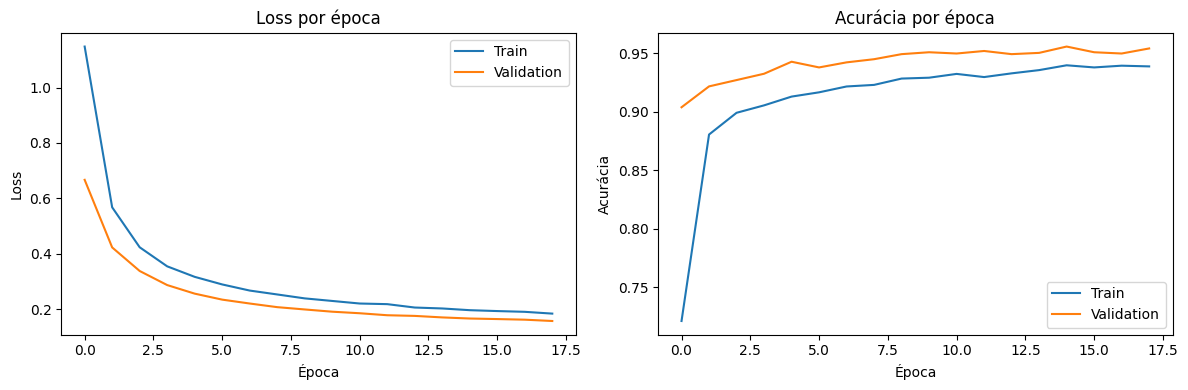

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_history['train_loss'], label='Train')
axes[0].plot(train_history['val_loss'], label='Validation')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss por época')
axes[0].legend()

axes[1].plot(train_history['train_acc'], label='Train')
axes[1].plot(train_history['val_acc'], label='Validation')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].set_title('Acurácia por época')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [ ]:
test_loss, test_acc = validate(model, testloader, criterion, device)
print(f"Loss do conjunto de teste: {test_loss}. Acurácia do conjunto de teste: {test_acc}")

Loss do conjunto de teste: 0.18577497350203023. Acurácia do conjunto de teste: 0.94


# Implementação do algoritmo ODIN

In [66]:
def check_distribution(model, data, loss_func=torch.nn.CrossEntropyLoss(), temperature=1000, threshold=0.1, perturbation=1e-4):
  """
  Delineamento do algoritmo:
    - Calcular softmax da entrada;
    - Processar a entrada usando o log da softmax e perturbação;
    - Calcular o softmax da entrada* processada e comparar com threshold.
  * Usando temperatura
  """
  is_list = isinstance(threshold, list) or isinstance(threshold, np.ndarray)
  counter = [0] * len(threshold) if is_list else 0

  all_scores = []

  model.to(device)

  for xb, yb in data:
    xb = xb.to(device)
    yb = yb.to(device)

    xb.requires_grad = True

    pred = model(xb)

    # Temperature scaling
    pred = pred / temperature

    # Calculando o gradiente
    labels = torch.zeros(xb.shape[0]).to(device)

    for i in range(xb.shape[0]):
      labels[i] = pred[i].argmax()

    labels = labels.long()
    loss = loss_func(pred, labels)
    loss.backward()

    gradient = (torch.ge(xb.grad, 0))
    gradient = (gradient.float() - 0.5) * 2

    with torch.no_grad():
      # Gerando novos inputs usando a fórmula:
      # x˜ = x - epsilon * sign(gradient_{wrt x}(log S(x, T)))
      new_input = xb + (-perturbation) * gradient
      new_output = model(new_input)
      new_output = new_output / temperature
      new_output = torch.nn.functional.softmax(new_output, dim=1)

      max_values = new_output.max(dim=1).values
      max_values.to('cpu')
      max_values = max_values.detach().cpu().numpy()
      all_scores.extend(max_values)

    if is_list:
      for i, delta in enumerate(threshold):
        counter[i] += (max_values <= delta).sum()
    else:
      counter += (max_values <= threshold).sum()

  return counter, np.array(all_scores)

In [67]:
def find_best_odin_params(model, oodset, idset, criterion, temperatures=None, thresholds=None, perturbations=None):
  if temperatures is None:
    temperatures = [1, 10, 100, 500, 1000]

  if thresholds is None:
    thresholds = np.arange(0.1, 1, 0.1)

  if perturbations is None:
    perturbations = np.arange(0, 0.004, 0.004/5)

  tests = list(itertools.product(temperatures, perturbations))

  history = []
  best_score = -np.inf
  best_params = None

  ooddata = DataLoader(oodset, batch_size=64, shuffle=True)
  n_ood_samples = len(oodset)

  iddata = DataLoader(idset, batch_size=64, shuffle=True)
  n_id_samples = len(idset)

  iteration = 0

  for T, epsilon in tests:
    n_oods, _ = check_distribution(model, ooddata, loss_func=criterion, temperature=T, threshold=thresholds, perturbation=epsilon)
    tpr = np.array(n_oods) / n_ood_samples

    n_oods, _ = check_distribution(model, iddata, loss_func=criterion, temperature=T, threshold=thresholds, perturbation=epsilon)
    fpr = np.array(n_oods) / n_id_samples

    scores = tpr - fpr
    best_idx = np.argmax(scores)
    best_delta = thresholds[best_idx]
    score = scores[best_idx]

    history.append({
            'Temperature': T, 'Threshold': best_delta, 'Perturbation': epsilon,
            'TPR': tpr[best_idx], 'FPR': fpr[best_idx], 'Score': score
            })

    if score > best_score:
      best_score = score
      best_params = {'Temperature': T, 'Threshold': best_delta, 'Perturbation': epsilon, 'TPR': tpr[best_idx], 'FPR': fpr[best_idx]}

    iteration += 1
    print(f"Iteração {iteration}")

  return best_params, pd.DataFrame(history)

# Melhores parâmetros para desvio semântico

In [64]:
oodset = Subset(ood_dataset, list(range(test_size)))

In [ ]:
best_params, historydf = find_best_odin_params(model, oodset, testset, criterion)

Iteração 1
Iteração 2
Iteração 3
Iteração 4
Iteração 5
Iteração 6
Iteração 7
Iteração 8
Iteração 9
Iteração 10
Iteração 11
Iteração 12
Iteração 13
Iteração 14
Iteração 15
Iteração 16
Iteração 17
Iteração 18
Iteração 19
Iteração 20
Iteração 21
Iteração 22
Iteração 23
Iteração 24
Iteração 25


In [ ]:
print(best_params)

{'Temperature': 1, 'Threshold': np.float64(0.9), 'Perturbation': np.float64(0.0), 'TPR': np.float64(0.7848648648648648), 'FPR': np.float64(0.2967567567567568)}


In [ ]:
best_params2, historydf2 = find_best_odin_params(model, oodset, testset, criterion, perturbations=np.arange(0.0, 0.1, 0.1/5))

Iteração 1
Iteração 2
Iteração 3
Iteração 4
Iteração 5
Iteração 6
Iteração 7
Iteração 8
Iteração 9
Iteração 10
Iteração 11
Iteração 12
Iteração 13
Iteração 14
Iteração 15
Iteração 16
Iteração 17
Iteração 18
Iteração 19
Iteração 20
Iteração 21
Iteração 22
Iteração 23
Iteração 24
Iteração 25


In [ ]:
print(best_params2)

{'Temperature': 1, 'Threshold': np.float64(0.9), 'Perturbation': np.float64(0.0), 'TPR': np.float64(0.7848648648648648), 'FPR': np.float64(0.2967567567567568)}


# Gráficos de ROC e AUC

In [ ]:
oodloader = DataLoader(oodset, batch_size=64, shuffle=True)

In [ ]:
T = float(best_params['Temperature'])
eps = float(best_params['Perturbation'])

_, ood_scores = check_distribution(model, oodloader, criterion, temperature=T, perturbation=eps)
_, id_scores = check_distribution(model, testloader, criterion, temperature=T, perturbation=eps)

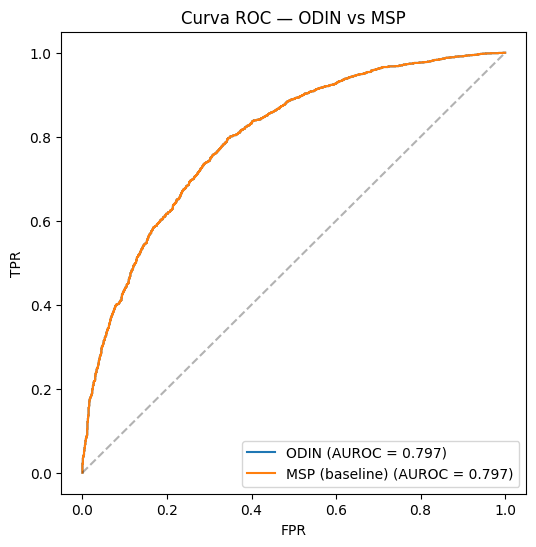

In [ ]:
def plot_roc(id_scores, ood_scores, label):
    y_true = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])
    y_score = np.concatenate([1 - id_scores, 1 - ood_scores])  # score baixo de softmax = mais "OOD-like"

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    plt.plot(fpr, tpr, label=f'{label} (AUROC = {auc:.3f})')
    return auc

plt.figure(figsize=(6, 6))
auc_odin = plot_roc(id_scores, ood_scores, 'ODIN')
auc_msp = plot_roc(id_scores, ood_scores, 'MSP (baseline)')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC — ODIN vs MSP')
plt.legend()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

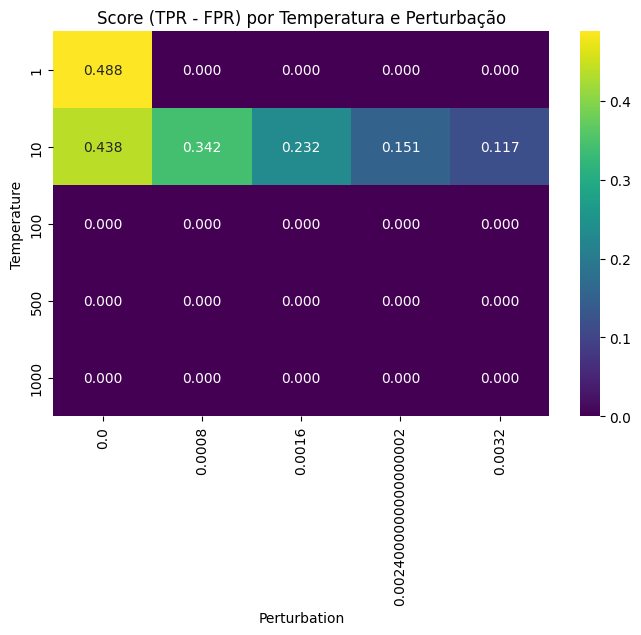

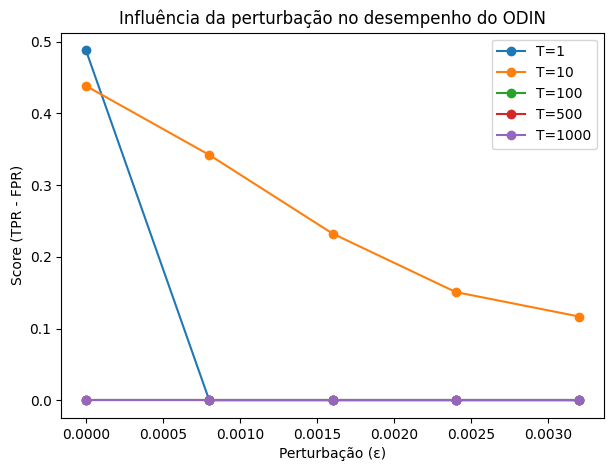

In [ ]:
import seaborn as sns

# Heatmap: Score (TPR-FPR) por combinação de T e epsilon
pivot = historydf.pivot(index='Temperature', columns='Perturbation', values='Score')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
plt.title('Score (TPR - FPR) por Temperatura e Perturbação')
plt.savefig('param_heatmap.png', dpi=150)
plt.show()

# Linha: como o score varia com a perturbação, para cada temperatura
plt.figure(figsize=(7, 5))
for T in historydf['Temperature'].unique():
    subset = historydf[historydf['Temperature'] == T]
    plt.plot(subset['Perturbation'], subset['Score'], marker='o', label=f'T={T}')
plt.xlabel('Perturbação (ε)')
plt.ylabel('Score (TPR - FPR)')
plt.title('Influência da perturbação no desempenho do ODIN')
plt.legend()
plt.savefig('param_influence.png', dpi=150)
plt.show()

# Teste 2

## Model setup

In [53]:
model2 = mobilenet_v2(torchvision.models.MobileNet_V2_Weights)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [48]:
conv_names = [name for name, layer in model2.named_modules() if isinstance(layer, torch.nn.Conv2d)]
print(conv_names)

['features.0.0', 'features.1.conv.0.0', 'features.1.conv.1', 'features.2.conv.0.0', 'features.2.conv.1.0', 'features.2.conv.2', 'features.3.conv.0.0', 'features.3.conv.1.0', 'features.3.conv.2', 'features.4.conv.0.0', 'features.4.conv.1.0', 'features.4.conv.2', 'features.5.conv.0.0', 'features.5.conv.1.0', 'features.5.conv.2', 'features.6.conv.0.0', 'features.6.conv.1.0', 'features.6.conv.2', 'features.7.conv.0.0', 'features.7.conv.1.0', 'features.7.conv.2', 'features.8.conv.0.0', 'features.8.conv.1.0', 'features.8.conv.2', 'features.9.conv.0.0', 'features.9.conv.1.0', 'features.9.conv.2', 'features.10.conv.0.0', 'features.10.conv.1.0', 'features.10.conv.2', 'features.11.conv.0.0', 'features.11.conv.1.0', 'features.11.conv.2', 'features.12.conv.0.0', 'features.12.conv.1.0', 'features.12.conv.2', 'features.13.conv.0.0', 'features.13.conv.1.0', 'features.13.conv.2', 'features.14.conv.0.0', 'features.14.conv.1.0', 'features.14.conv.2', 'features.15.conv.0.0', 'features.15.conv.1.0', 'feat

In [54]:
for name, param in model2.named_parameters():
  if conv_names[-1][:-2] not in name:
    param.requires_grad = False

In [56]:
in_features = model2.classifier[1].in_features

model2.classifier = torch.nn.Sequential(
    torch.nn.Linear(in_features, num_classes)
)

model2.classifier

Sequential(
  (0): Linear(in_features=1280, out_features=7, bias=True)
)

## Treinamento


In [58]:
learning_rate = 1e-4
weight_decay = 1e-2
optimizer2 = torch.optim.AdamW(model2.parameters(), lr=learning_rate, weight_decay=weight_decay)
epochs = 20
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
train_history2 = fit(model2, epochs, trainloader, devloader, optimizer2, criterion, device)

Epoch 1/20 | Train Loss: 0.5459 Acc: 0.8626 | Val Loss: 0.2216 Acc: 0.9449
Epoch 2/20 | Train Loss: 0.2214 Acc: 0.9328 | Val Loss: 0.1603 Acc: 0.9530
Epoch 3/20 | Train Loss: 0.1766 Acc: 0.9448 | Val Loss: 0.1398 Acc: 0.9611
Epoch 4/20 | Train Loss: 0.1518 Acc: 0.9518 | Val Loss: 0.1275 Acc: 0.9600
Epoch 5/20 | Train Loss: 0.1332 Acc: 0.9578 | Val Loss: 0.1216 Acc: 0.9600
Epoch 6/20 | Train Loss: 0.1237 Acc: 0.9609 | Val Loss: 0.1121 Acc: 0.9622
Epoch 7/20 | Train Loss: 0.1128 Acc: 0.9638 | Val Loss: 0.1052 Acc: 0.9659
Epoch 8/20 | Train Loss: 0.1047 Acc: 0.9659 | Val Loss: 0.1041 Acc: 0.9654
Epoch 9/20 | Train Loss: 0.0951 Acc: 0.9701 | Val Loss: 0.1033 Acc: 0.9670
Epoch 10/20 | Train Loss: 0.0902 Acc: 0.9712 | Val Loss: 0.1009 Acc: 0.9659
Epoch 11/20 | Train Loss: 0.0857 Acc: 0.9721 | Val Loss: 0.0971 Acc: 0.9676
Epoch 12/20 | Train Loss: 0.0817 Acc: 0.9736 | Val Loss: 0.0944 Acc: 0.9681
Epoch 13/20 | Train Loss: 0.0761 Acc: 0.9749 | Val Loss: 0.0936 Acc: 0.9681
Epoch 14/20 | Train L

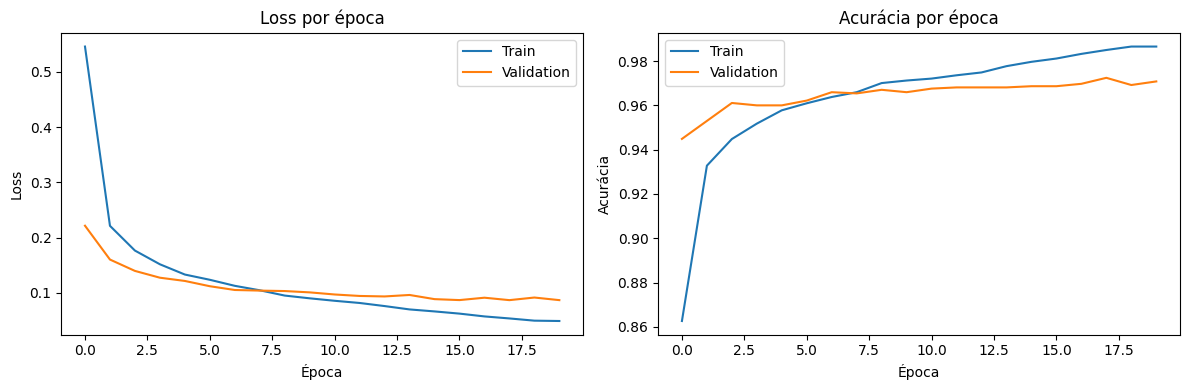

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_history2['train_loss'], label='Train')
axes[0].plot(train_history2['val_loss'], label='Validation')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss por época')
axes[0].legend()

axes[1].plot(train_history2['train_acc'], label='Train')
axes[1].plot(train_history2['val_acc'], label='Validation')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].set_title('Acurácia por época')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [62]:
test_loss2, test_acc2 = validate(model2, testloader, criterion, device)
print(f"Loss do conjunto de teste: {test_loss2}. Acurácia do conjunto de teste: {test_acc2}")

Loss do conjunto de teste: 0.10418957829475403. Acurácia do conjunto de teste: 0.9648648648648649


## Classificação de OOD

In [68]:
best_params2, historydf2 = find_best_odin_params(model2, oodset, testset, criterion)

Iteração 1
Iteração 2
Iteração 3
Iteração 4
Iteração 5
Iteração 6
Iteração 7
Iteração 8
Iteração 9
Iteração 10
Iteração 11
Iteração 12
Iteração 13
Iteração 14
Iteração 15
Iteração 16
Iteração 17
Iteração 18
Iteração 19
Iteração 20
Iteração 21
Iteração 22
Iteração 23
Iteração 24
Iteração 25


In [69]:
best_params2

{'Temperature': 10,
 'Threshold': np.float64(0.30000000000000004),
 'Perturbation': np.float64(0.0),
 'TPR': np.float64(0.8821621621621621),
 'FPR': np.float64(0.3021621621621622)}